# GrC Image Matting on CBIS-DDSM - Data Preparation

## Section 1 - Environment, Drive mount, and dataset acquisition

Same structure as the MIAS phase: dependencies, Drive mount, a shared
`config.json`, then a Kaggle pull. 

In [ ]:
# Install and import
!pip install -q opencv-python scikit-learn scipy Pillow tqdm joblib

import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
warnings.filterwarnings('ignore')
print("Imports OK.")

Imports OK.


In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

DRIVE_ROOT  = "/content/drive/MyDrive/cbis_ddsm_grc_project"
os.makedirs(DRIVE_ROOT, exist_ok=True)
print(f"Project root: {DRIVE_ROOT}")

Mounted at /content/drive
Project root: /content/drive/MyDrive/cbis_ddsm_grc_project


In [ ]:
# Config file to be used by all the models
CONFIG = {
    "SEED": 42,
    "DRIVE_ROOT": DRIVE_ROOT,
    "DATASET_DIR": "/content/cbis_ddsm",
    "KAGGLE_SLUG": "awsaf49/cbis-ddsm-breast-cancer-image-dataset",

    "MARGIN_TO_CLASS": {
        "CIRCUMSCRIBED": "CIRC",
        "SPICULATED":    "SPIC",
        "ILL_DEFINED":   "MISC",
    },
    "TARGET_CLASSES": ["CIRC", "SPIC", "MISC"],   
    "LESIONS_PER_CLASS": 90,                       

    "CLAHE_CLIP_LIMIT": 2.0,
    "CLAHE_TILE_FINE": [8, 8],
    "CLAHE_TILE_COARSE": [16, 16],
    "ROI_MAX_SIZE": None,
    "TRIMAP_ERODE_ITERS": 6,
    "TRIMAP_DILATE_ITERS": 10,

    "LAMBDA_VAL": 5.0,
    "PATCH_SIZES": [3, 5, 7],
    "PATCH_SINGLE": 5,

    "K_CANDIDATES": [6, 8, 10, 12],   
    "HISTOGRAM_WINDOW": 7,
    "HISTOGRAM_STRIDE": 1,

    "SVM_C_VALUES": [0.1, 1, 10],
    "SVM_GAMMA_VALUES": ["scale", "auto"],
    "HYBRID_GAMMA": 0.9,

    "MAX_NODES": 2500,
    "LAMBDA_PROPAGATION": 100.0,

    "ALPHA_THRESHOLD": 0.5,
    "HD95_PERCENTILE": 95,
}

DIR_MAP = {
    "OUTPUTS_DIR": "outputs", "PREPROCESSED_DIR": "preprocessed",
    "TRIMAPS_DIR": "trimaps", "ALPHAS_DIR": "alpha_maps",
    "MODELS_DIR": "models", "RESULTS_DIR": "results",
    "LOGS_DIR": "logs", "FIGURES_DIR": "figures",
}
for var, folder in DIR_MAP.items():
    p = os.path.join(DRIVE_ROOT, folder)
    os.makedirs(p, exist_ok=True)
    CONFIG[var] = p
CONFIG["ALPHA_MAPS_DIR"] = CONFIG["ALPHAS_DIR"]   # harmless alias

with open(os.path.join(DRIVE_ROOT, "config.json"), 'w') as f:
    json.dump(CONFIG, f, indent=2)

globals().update(CONFIG)
SEED = CONFIG["SEED"]
random.seed(SEED); np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print("config.json written. Target classes:", TARGET_CLASSES)
print(f"Lesions per class: {LESIONS_PER_CLASS} (expect ~450 to 500 images)")

config.json written. Target classes: ['CIRC', 'SPIC', 'MISC']
Lesions per class: 90 (expect ~450 to 500 images)


In [ ]:
from google.colab import files

if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("Upload your kaggle.json now.")
    up = files.upload()
    os.makedirs('/root/.kaggle', exist_ok=True)
    # handle either a direct kaggle.json or a renamed upload
    src = 'kaggle.json' if os.path.exists('kaggle.json') else list(up.keys())[0]
    os.replace(src, '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print("kaggle.json installed.")
else:
    print("kaggle.json already present.")

Upload your kaggle.json now.


Saving kaggle (1).json to kaggle (1).json
kaggle.json installed.


In [ ]:
os.makedirs(DATASET_DIR, exist_ok=True)

def count_jpgs(root):
    n = 0
    for _, _, fs in os.walk(root):
        n += sum(1 for f in fs if f.lower().endswith(('.jpg', '.jpeg', '.png')))
    return n

if count_jpgs(DATASET_DIR) < 1000:
    !pip install -q kaggle
    !kaggle datasets download -d {CONFIG['KAGGLE_SLUG']} -p {DATASET_DIR} --unzip
else:
    print("Dataset already present, skipping download.")

print("Image files found:", count_jpgs(DATASET_DIR))

Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
100% 4.95G/4.95G [00:37<00:00, 143MB/s]

Image files found: 10237


In [ ]:
# Locate the CSV folder, image root, and dicom_info map
def find_dir_containing(root, needle):
    for dp, _, fs in os.walk(root):
        if any(needle in f for f in fs):
            return dp
    return None

CSV_DIR = find_dir_containing(DATASET_DIR, "mass_case_description_train")
JPEG_DIR = None
for dp, dns, _ in os.walk(DATASET_DIR):
    if os.path.basename(dp).lower() == "jpeg":
        JPEG_DIR = dp
        break

print("CSV dir  :", CSV_DIR)
print("JPEG dir :", JPEG_DIR)
assert CSV_DIR and JPEG_DIR, "Could not locate csv/ or jpeg/ folders. Check the download."

CONFIG['CSV_DIR']  = CSV_DIR
CONFIG['JPEG_DIR'] = JPEG_DIR

dicom_info_path = os.path.join(CSV_DIR, "dicom_info.csv")
CONFIG['DICOM_INFO_PATH'] = dicom_info_path if os.path.exists(dicom_info_path) else None
print("dicom_info.csv:", CONFIG['DICOM_INFO_PATH'])

with open(os.path.join(DRIVE_ROOT, "config.json"), 'w') as f:
    json.dump(CONFIG, f, indent=2)
print("config.json updated with dataset paths.")

CSV dir  : /content/cbis_ddsm/csv
JPEG dir : /content/cbis_ddsm/jpeg
dicom_info.csv: /content/cbis_ddsm/csv/dicom_info.csv
config.json updated with dataset paths.


In [ ]:
# Verification
def verify_section1():
    checks = {
        "Drive mounted"        : os.path.isdir(DRIVE_ROOT),
        "config.json written"  : os.path.exists(os.path.join(DRIVE_ROOT, "config.json")),
        "Dataset downloaded"   : count_jpgs(DATASET_DIR) > 1000,
        "CSV dir found"        : CSV_DIR is not None,
        "JPEG dir found"       : JPEG_DIR is not None,
        "Mass train CSV"       : os.path.exists(os.path.join(
                                     CSV_DIR, "mass_case_description_train_set.csv")),
        "Mass test CSV"        : os.path.exists(os.path.join(
                                     CSV_DIR, "mass_case_description_test_set.csv")),
    }
    print("=" * 52)
    print("SECTION 1 VERIFICATION")
    print("=" * 52)
    ok = True
    for k, v in checks.items():
        print(f"  {'OK ' if v else 'FAIL'}  {k}")
        ok = ok and v
    print("=" * 52)
    print("Proceed to notebook 2." if ok else "Fix failures first.")
    return ok

verify_section1()

SECTION 1 VERIFICATION
  OK   Drive mounted
  OK   config.json written
  OK   Dataset downloaded
  OK   CSV dir found
  OK   JPEG dir found
  OK   Mass train CSV
  OK   Mass test CSV
Proceed to notebook 2.


True

## Section 2 - Metadata, path resolution, class mapping, and lesion grouping

This section handled the heaviest data engineering part of this phase.

**Path resolution.** Naively matching the CSV paths against the mirror's layout
resolved only 103 of 1696 rows. The crop and the mask share the same series-UID
folder in roughly 93% of rows and are distinguishable by content, not by filename.
They are separated by a per-pair binary-score test - whichever of the two candidates
is closer to binary is the mask - which resolves 1593 of 1696.

**Column swap.** Some CBIS-DDSM mirrors ship with the cropped-image and mask columns
transposed.

**Class mapping.** The `mass margins` field maps to the MIAS-equivalent labels
(CIRCUMSCRIBED → CIRC, SPICULATED → SPIC, ILL_DEFINED → MISC). Only pure
single-label rows are used. 

**Lesion grouping.** CC and MLO are two views of the *same* lesion.
Splitting by image would put both views of one lesion on
opposite sides of the train/test boundary. Every split downstream is therefore
grouped by `lesion_key`. 

In [ ]:
# Load and concatenate the mass description CSVs
train_csv = pd.read_csv(os.path.join(CSV_DIR, "mass_case_description_train_set.csv"))
test_csv  = pd.read_csv(os.path.join(CSV_DIR, "mass_case_description_test_set.csv"))
raw = pd.concat([train_csv, test_csv], ignore_index=True)

raw.columns = [c.strip() for c in raw.columns]
print(f"Combined mass rows: {len(raw)}")
print("Columns:", list(raw.columns))

COL_PATIENT = 'patient_id'
COL_BREAST  = 'left or right breast'
COL_VIEW    = 'image view'
COL_ABN     = 'abnormality id'
COL_MARGIN  = 'mass margins'
COL_CROP    = 'cropped image file path'
COL_MASK    = 'ROI mask file path'
for c in [COL_PATIENT, COL_BREAST, COL_VIEW, COL_ABN, COL_MARGIN, COL_CROP, COL_MASK]:
    assert c in raw.columns, f"Expected column missing: {c}"
print("All expected columns present.")

Combined mass rows: 1696
Columns: ['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']
All expected columns present.


In [ ]:
# Resolve real image paths from the awsaf49 mirror
import glob
from collections import defaultdict

print("Indexing image files (one-time, may take a minute)...")
all_jpgs = glob.glob(os.path.join(JPEG_DIR, "*", "*.jpg"))
print(f"Indexed {len(all_jpgs)} jpg files.")

by_hash = defaultdict(list)
for p in all_jpgs:
    by_hash[os.path.basename(os.path.dirname(p))].append(p)

def series_folder(csv_path):
    if not isinstance(csv_path, str) or not csv_path.strip():
        return None
    parts = csv_path.replace('\\', '/').strip().split('/')
    return parts[-2] if len(parts) >= 2 else None

def binary_fraction(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    norm = img.astype(np.float32) / 255.0
    return float(((norm < 0.05) | (norm > 0.95)).mean())

def resolve_pair(csv_crop_path):
    folder = series_folder(csv_crop_path)
    if folder is None or folder not in by_hash:
        return None, None, "folder_not_found"
    files = by_hash[folder]
    if len(files) == 1:
        return None, None, "only_one_file_in_folder"
    if len(files) > 2:
        return None, None, f"unexpected_file_count_{len(files)}"
    scores = [binary_fraction(f) for f in files]
    if any(s is None for s in scores):
        return None, None, "unreadable_candidate"
    mask_idx = int(np.argmax(scores))
    crop_idx = 1 - mask_idx
    note = "ok" if abs(scores[0] - scores[1]) > 0.15 else "low_confidence_gap"
    return files[crop_idx], files[mask_idx], note

print("Resolving crop/mask pairs by content (this reads every candidate pair once)...")
resolved_crop, resolved_mask, resolved_note = [], [], []
for _, row in tqdm(raw.iterrows(), total=len(raw)):
    c, m, note = resolve_pair(row[COL_CROP])
    resolved_crop.append(c); resolved_mask.append(m); resolved_note.append(note)

raw['crop_path'] = resolved_crop
raw['mask_path'] = resolved_mask
raw['resolve_note'] = resolved_note

print(f"\nResolved both crop and mask: {raw['crop_path'].notna().sum()} / {len(raw)}")
print("Resolve note breakdown:")
print(raw['resolve_note'].value_counts())
print(f"\nLow-confidence disambiguations (worth a manual spot-check): "
      f"{(raw['resolve_note']=='low_confidence_gap').sum()}")

resolved = raw[raw['crop_path'].notna() & raw['mask_path'].notna()].copy()

Indexing image files (one-time, may take a minute)...
Indexed 10237 jpg files.
Resolving crop/mask pairs by content (this reads every candidate pair once)...


100%|██████████| 1696/1696 [03:09<00:00,  8.94it/s]


Resolved both crop and mask: 1593 / 1696
Resolve note breakdown:
resolve_note
ok                         1593
only_one_file_in_folder     103
Name: count, dtype: int64

Low-confidence disambiguations (worth a manual spot-check): 0


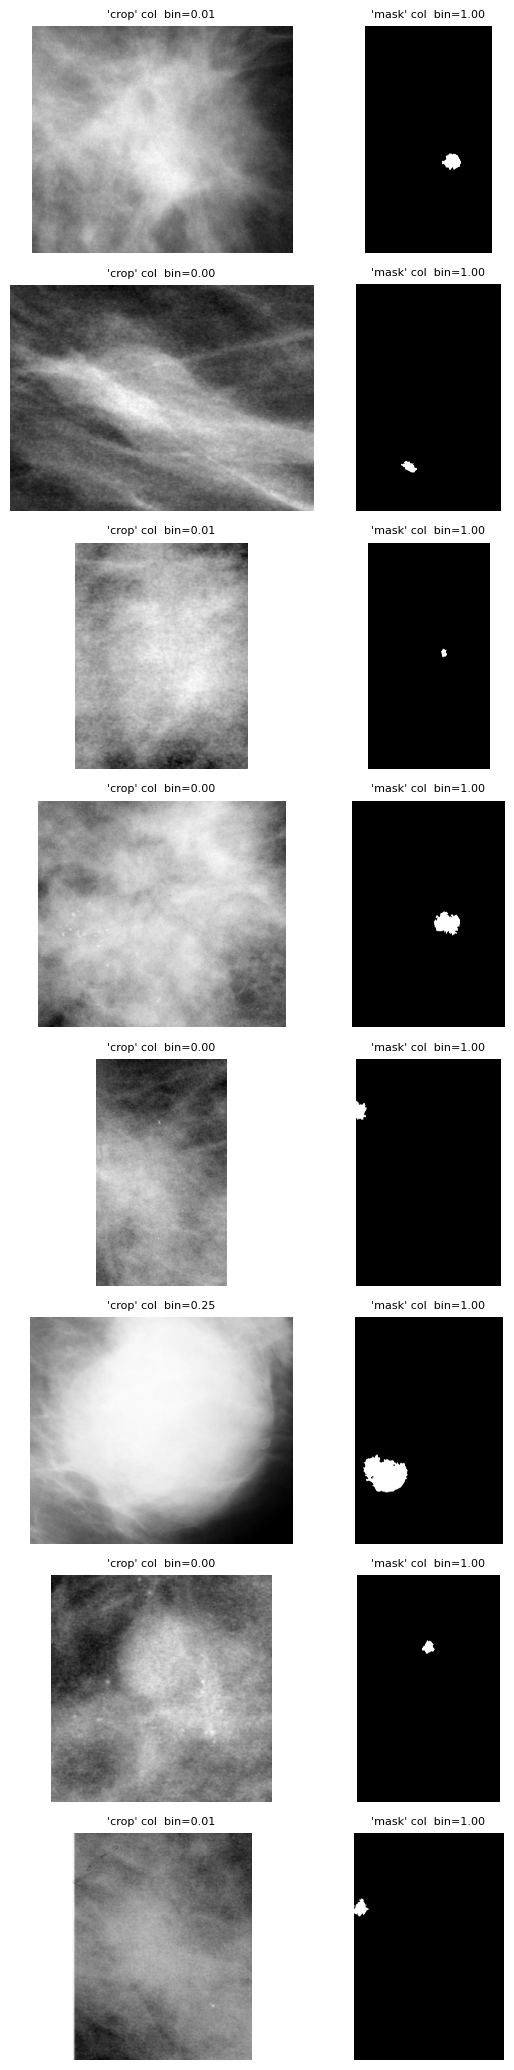


Mean binary-score of 'crop' column : 0.035
Mean binary-score of 'mask' column : 1.000

Columns look correct (mask column is more binary than crop column).


In [ ]:
# Column-swap sanity check
def binary_score(img):
    """Fraction of pixels near 0 or near 255. High => looks like a mask."""
    near = ((img < 15) | (img > 240)).mean()
    return float(near)

def load_gray(path):
    im = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return im

sample = resolved.sample(n=min(8, len(resolved)), random_state=SEED)
crop_bin, mask_bin = [], []
fig, axes = plt.subplots(len(sample), 2, figsize=(6, 2.6*len(sample)))
for r, (_, row) in enumerate(sample.iterrows()):
    c_img = load_gray(row['crop_path'])
    m_img = load_gray(row['mask_path'])
    if c_img is None or m_img is None:
        continue
    crop_bin.append(binary_score(c_img))
    mask_bin.append(binary_score(m_img))
    axes[r, 0].imshow(c_img, cmap='gray'); axes[r, 0].set_title(f"'crop' col  bin={binary_score(c_img):.2f}", fontsize=8)
    axes[r, 1].imshow(m_img, cmap='gray'); axes[r, 1].set_title(f"'mask' col  bin={binary_score(m_img):.2f}", fontsize=8)
    axes[r, 0].axis('off'); axes[r, 1].axis('off')
plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR, "section2_swap_check.png"), dpi=130, bbox_inches='tight')
plt.show()

mean_crop_bin = np.mean(crop_bin)
mean_mask_bin = np.mean(mask_bin)
print(f"\nMean binary-score of 'crop' column : {mean_crop_bin:.3f}")
print(f"Mean binary-score of 'mask' column : {mean_mask_bin:.3f}")

COLUMNS_SWAPPED = mean_mask_bin < mean_crop_bin
if COLUMNS_SWAPPED:
    print("\n>>> SWAP DETECTED: the 'crop' column holds masks. Swapping in code. <<<")
    resolved['crop_path'], resolved['mask_path'] = resolved['mask_path'], resolved['crop_path']
else:
    print("\nColumns look correct (mask column is more binary than crop column).")

with open(os.path.join(LOGS_DIR, "swap_check.json"), 'w') as f:
    json.dump({'crop_bin': float(mean_crop_bin), 'mask_bin': float(mean_mask_bin),
               'swapped': bool(COLUMNS_SWAPPED)}, f, indent=2)

In [ ]:
# Class mapping 
resolved['margin_clean'] = (resolved[COL_MARGIN].astype(str)
                            .str.strip().str.upper())

def map_class(margin):
    if '-' in margin or margin in ('NAN', 'NONE', ''):
        return None
    return MARGIN_TO_CLASS.get(margin, None)

resolved['class'] = resolved['margin_clean'].apply(map_class)
mass = resolved[resolved['class'].notna()].copy()

print("Rows after pure-class filtering:", len(mass))
print("\nMargin values excluded (top):")
excluded = resolved[resolved['class'].isna()]['margin_clean'].value_counts().head(10)
print(excluded.to_string())
print("\nRows per class (image-level, before lesion subset):")
print(mass['class'].value_counts().to_string())

Rows after pure-class filtering: 1082

Margin values excluded (top):
margin_clean
OBSCURED                           199
MICROLOBULATED                     118
NAN                                 59
ILL_DEFINED-SPICULATED              30
CIRCUMSCRIBED-ILL_DEFINED           29
OBSCURED-ILL_DEFINED                24
CIRCUMSCRIBED-OBSCURED              22
OBSCURED-ILL_DEFINED-SPICULATED      5
MICROLOBULATED-ILL_DEFINED           5
OBSCURED-SPICULATED                  4

Rows per class (image-level, before lesion subset):
class
CIRC    370
SPIC    356
MISC    356


In [ ]:
# Build lesion keys and resolve discordant CC/MLO labels
def norm_breast(b):
    return str(b).strip().upper()

mass['lesion_key'] = (mass[COL_PATIENT].astype(str) + "_" +
                      mass[COL_BREAST].apply(norm_breast) + "_" +
                      mass[COL_ABN].astype(str))
mass['view'] = mass[COL_VIEW].astype(str).str.strip().str.upper()

discordant = []
lesion_class = {}
for lkey, grp in mass.groupby('lesion_key'):
    classes = set(grp['class'])
    if len(classes) > 1:
        cc_rows = grp[grp['view'] == 'CC']
        chosen = cc_rows['class'].iloc[0] if len(cc_rows) else grp['class'].iloc[0]
        discordant.append({'lesion_key': lkey,
                           'classes': sorted(classes),
                           'chosen': chosen,
                           'rule': 'CC' if len(cc_rows) else 'first-available'})
    else:
        chosen = grp['class'].iloc[0]
    lesion_class[lkey] = chosen

mass['class'] = mass['lesion_key'].map(lesion_class)
print(f"Discordant lesions resolved (CC preferred): {len(discordant)}")
if discordant:
    pd.DataFrame(discordant).to_csv(
        os.path.join(LOGS_DIR, "discordant_lesions.csv"), index=False)
    print("Logged to discordant_lesions.csv. Examples:")
    for d in discordant[:5]:
        print(f"  {d['lesion_key']}: {d['classes']} -> {d['chosen']} ({d['rule']})")

Discordant lesions resolved (CC preferred): 32
Logged to discordant_lesions.csv. Examples:
  P_00017_LEFT_1: ['CIRC', 'MISC'] -> CIRC (CC)
  P_00027_RIGHT_1: ['CIRC', 'MISC'] -> MISC (CC)
  P_00133_LEFT_1: ['MISC', 'SPIC'] -> SPIC (CC)
  P_00187_LEFT_1: ['CIRC', 'MISC'] -> CIRC (CC)
  P_00224_RIGHT_1: ['CIRC', 'MISC'] -> MISC (CC)


In [ ]:
# Stratified lesion-level subset
img_df = mass.drop_duplicates(subset=['lesion_key', 'view']).copy()
img_df['image_id'] = img_df['lesion_key'] + "_" + img_df['view']

lesion_views = img_df.groupby(['class', 'lesion_key'])['view'].apply(set).reset_index()
lesion_views['n_views'] = lesion_views['view'].apply(len)

rng = np.random.default_rng(SEED)
selected_lesions = []
for cls in TARGET_CLASSES:
    pool = lesion_views[lesion_views['class'] == cls].copy()
    pool = pool.sort_values('n_views', ascending=False)
    two = pool[pool['n_views'] == 2]['lesion_key'].tolist()
    one = pool[pool['n_views'] == 1]['lesion_key'].tolist()
    rng.shuffle(two); rng.shuffle(one)
    ordered = two + one
    take = min(LESIONS_PER_CLASS, len(ordered))
    selected_lesions.extend(ordered[:take])
    print(f"  {cls}: {take} lesions selected "
          f"({sum(1 for l in ordered[:take] if l in set(two))} with both views)")

final_df = img_df[img_df['lesion_key'].isin(selected_lesions)].copy()
final_df = final_df[['image_id', 'lesion_key', 'class', 'view',
                     'crop_path', 'mask_path', COL_PATIENT]].reset_index(drop=True)
final_df.columns = ['image_id', 'lesion_key', 'class', 'view',
                    'crop_path', 'mask_path', 'patient_id']

print(f"\nFinal subset: {len(final_df)} images from {final_df['lesion_key'].nunique()} lesions")
print("Images per class:")
print(final_df['class'].value_counts().to_string())

  CIRC: 90 lesions selected (90 with both views)
  SPIC: 90 lesions selected (90 with both views)
  MISC: 90 lesions selected (90 with both views)

Final subset: 540 images from 270 lesions
Images per class:
class
SPIC    180
MISC    180
CIRC    180


In [ ]:
# Save outputs
final_df.to_csv(os.path.join(RESULTS_DIR, "final_df.csv"), index=False)

summary = {
    'total_mass_rows'      : int(len(raw)),
    'resolved_rows'        : int(len(resolved)),
    'columns_swapped'      : bool(COLUMNS_SWAPPED),
    'pure_class_rows'      : int(len(mass)),
    'discordant_lesions'   : int(len(discordant)),
    'selected_lesions'     : int(final_df['lesion_key'].nunique()),
    'selected_images'      : int(len(final_df)),
    'images_per_class'     : final_df['class'].value_counts().to_dict(),
    'lesions_per_class'    : final_df.groupby('class')['lesion_key'].nunique().to_dict(),
}
with open(os.path.join(RESULTS_DIR, "section2_summary.json"), 'w') as f:
    json.dump(summary, f, indent=2)
print("Saved final_df.csv and section2_summary.json")
print(json.dumps(summary, indent=2))

Saved final_df.csv and section2_summary.json
{
  "total_mass_rows": 1696,
  "resolved_rows": 1593,
  "columns_swapped": false,
  "pure_class_rows": 1082,
  "discordant_lesions": 32,
  "selected_lesions": 270,
  "selected_images": 540,
  "images_per_class": {
    "SPIC": 180,
    "MISC": 180,
    "CIRC": 180
  },
  "lesions_per_class": {
    "CIRC": 90,
    "MISC": 90,
    "SPIC": 90
  }
}


In [ ]:
# Verification
def verify_section2():
    n_img = len(final_df)
    checks = {
        "final_df built"          : n_img > 0,
        "3 classes only (no NORM)": set(final_df['class']) <= set(TARGET_CLASSES),
        "all 3 classes present"   : set(final_df['class']) == set(TARGET_CLASSES),
        "image count in 450-550"  : 400 <= n_img <= 550,
        "crop paths exist"        : final_df['crop_path'].apply(os.path.exists).all(),
        "mask paths exist"        : final_df['mask_path'].apply(os.path.exists).all(),
        "lesion_key present"      : final_df['lesion_key'].notna().all(),
        "swap check logged"       : os.path.exists(os.path.join(LOGS_DIR, "swap_check.json")),
        "saved to Drive"          : os.path.exists(os.path.join(RESULTS_DIR, "final_df.csv")),
    }
    print("=" * 52)
    print("SECTION 2 VERIFICATION")
    print("=" * 52)
    ok = True
    for k, v in checks.items():
        print(f"  {'OK ' if v else 'FAIL'}  {k}")
        ok = ok and v
    print("=" * 52)
    if not (400 <= n_img <= 550):
        print(f"Note: image count is {n_img}. Adjust LESIONS_PER_CLASS in config if")
        print("you want to hit the 450-500 target more precisely.")
    print("Proceed to notebook 3." if ok else "Review failures.")
    return ok

verify_section2()

SECTION 2 VERIFICATION
  OK   final_df built
  OK   3 classes only (no NORM)
  OK   all 3 classes present
  OK   image count in 450-550
  OK   crop paths exist
  OK   mask paths exist
  OK   lesion_key present
  OK   swap check logged
  OK   saved to Drive
Proceed to notebook 3.


True

## Section 3 - Crop sizing, multi-scale CLAHE, and trimaps from the real mask

Loads each crop/mask pair, tightens the loosely-padded provided crops, inspects the
real crop-size distribution before choosing a resolution cap from it, then applies
**Modification 1 (multi-scale CLAHE)**.

In [ ]:
# Load the final_df from drive
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

DRIVE_ROOT = "/content/drive/MyDrive/cbis_ddsm_grc_project"
CONFIG = json.load(open(os.path.join(DRIVE_ROOT, "config.json")))
globals().update(CONFIG)
SEED = CONFIG["SEED"]
random.seed(SEED); np.random.seed(SEED)

final_df = pd.read_csv(os.path.join(RESULTS_DIR, "final_df.csv"))
print(f"Loaded final_df: {len(final_df)} images")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded final_df: 540 images


In [ ]:
# Load crop/mask, then tighten the crop
ROI_MARGIN_FACTOR  = 0.7   
ROI_MARGIN_MIN_PX  = 40    

def tighten_to_mask(crop, mask_bin):
    """Crop both crop and mask to the mask's bounding box + margin.
    Returns (tight_crop, tight_mask_bin) or None if mask is somehow empty."""
    ys, xs = np.where(mask_bin)
    if len(ys) == 0:
        return None
    r0, r1 = ys.min(), ys.max()
    c0, c1 = xs.min(), xs.max()
    bbox_h, bbox_w = (r1 - r0 + 1), (c1 - c0 + 1)
    margin = max(int(round(ROI_MARGIN_FACTOR * max(bbox_h, bbox_w))), ROI_MARGIN_MIN_PX)

    h, w = crop.shape
    R0 = max(0, r0 - margin); R1 = min(h, r1 + margin + 1)
    C0 = max(0, c0 - margin); C1 = min(w, c1 + margin + 1)

    return crop[R0:R1, C0:C1], mask_bin[R0:R1, C0:C1]

def load_gray(path):
    if not isinstance(path, str) or not os.path.exists(path):
        return None
    return cv2.imread(path, cv2.IMREAD_GRAYSCALE)

FAILED = []
loaded = {}
tighten_stats = []  

for _, row in tqdm(final_df.iterrows(), total=len(final_df), desc="loading"):
    iid = row['image_id']
    crop = load_gray(row['crop_path'])
    mask = load_gray(row['mask_path'])
    if crop is None or mask is None:
        FAILED.append({'image_id': iid, 'reason': 'file unreadable'}); continue
    if mask.shape != crop.shape:
        mask = cv2.resize(mask, (crop.shape[1], crop.shape[0]),
                          interpolation=cv2.INTER_NEAREST)
    mbin = (mask > 127)
    if mbin.sum() < 20:
        FAILED.append({'image_id': iid, 'reason': 'empty mask'}); continue

    result = tighten_to_mask(crop, mbin)
    if result is None:
        FAILED.append({'image_id': iid, 'reason': 'tighten_failed'}); continue
    tight_crop, tight_mbin = result

    tighten_stats.append({
        'orig_size': crop.shape[0] * crop.shape[1],
        'tight_size': tight_crop.shape[0] * tight_crop.shape[1],
    })

    loaded[iid] = {'crop': tight_crop, 'mask': (tight_mbin.astype(np.uint8) * 255),
                   'class': row['class'], 'lesion_key': row['lesion_key'],
                   'view': row['view']}

final_df_loaded = final_df[final_df['image_id'].isin(loaded)].reset_index(drop=True)
print(f"\nLoaded {len(loaded)} pairs, {len(FAILED)} failed.")
if FAILED:
    print(FAILED[:10])
with open(os.path.join(LOGS_DIR, "failed_cases_section3.json"), 'w') as f:
    json.dump(FAILED, f, indent=2)

# Sanity check
if tighten_stats:
    orig_sizes  = np.array([s['orig_size'] for s in tighten_stats])
    tight_sizes = np.array([s['tight_size'] for s in tighten_stats])
    shrink_pct  = 100 * (1 - tight_sizes.mean() / orig_sizes.mean())
    print(f"\nMean original crop area: {orig_sizes.mean():.0f} px")
    print(f"Mean tightened crop area: {tight_sizes.mean():.0f} px")
    print(f"Average shrink: {shrink_pct:.1f}%")
    print("(should be a substantial reduction, given the ~0.3% foreground")
    print(" fraction measured earlier -- this is the whole point of the fix)")

loading: 100%|██████████| 540/540 [00:15<00:00, 34.04it/s]


Loaded 537 pairs, 3 failed.
[{'image_id': 'P_00106_LEFT_1_CC', 'reason': 'empty mask'}, {'image_id': 'P_00342_RIGHT_1_CC', 'reason': 'empty mask'}, {'image_id': 'P_01039_RIGHT_3_MLO', 'reason': 'empty mask'}]

Mean original crop area: 153677 px
Mean tightened crop area: 21627 px
Average shrink: 85.9%
(should be a substantial reduction, given the ~0.3% foreground
 fraction measured earlier -- this is the whole point of the fix)


Crop max-dimension distribution (pixels):
  min 73, median 110, mean 138, max 754
  10th percentile: 92
  25th percentile: 99
  50th percentile: 110
  75th percentile: 135
  90th percentile: 212
  95th percentile: 288
  99th percentile: 542

Chosen resolution cap (ROI_MAX_SIZE): 256 px
Crops above the cap (will be downscaled): 40 / 537


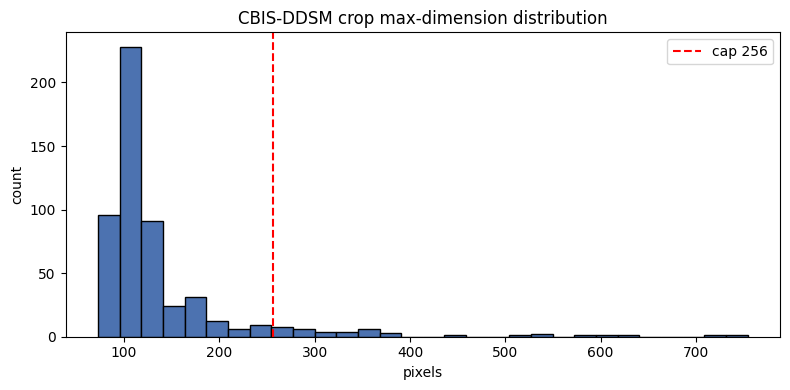

Saved ROI_MAX_SIZE to config.json


In [ ]:
# Inspect crop-size distribution, choose a resolution cap
sizes = np.array([max(d['crop'].shape) for d in loaded.values()])
pct = {p: int(np.percentile(sizes, p)) for p in [10, 25, 50, 75, 90, 95, 99]}
print("Crop max-dimension distribution (pixels):")
print(f"  min {sizes.min()}, median {int(np.median(sizes))}, "
      f"mean {int(sizes.mean())}, max {sizes.max()}")
for p, v in pct.items():
    print(f"  {p}th percentile: {v}")

cap = int(np.percentile(sizes, 90))
cap = max(256, int(round(cap / 32) * 32))
ROI_MAX_SIZE = cap
print(f"\nChosen resolution cap (ROI_MAX_SIZE): {ROI_MAX_SIZE} px")
print(f"Crops above the cap (will be downscaled): {(sizes > ROI_MAX_SIZE).sum()} / {len(sizes)}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sizes, bins=30, color='#4C72B0', edgecolor='black')
ax.axvline(ROI_MAX_SIZE, color='red', linestyle='--', label=f'cap {ROI_MAX_SIZE}')
ax.set(title="CBIS-DDSM crop max-dimension distribution", xlabel="pixels", ylabel="count")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "section4_size_distribution.png"), dpi=130, bbox_inches='tight')
plt.show()

CONFIG['ROI_MAX_SIZE'] = ROI_MAX_SIZE
with open(os.path.join(DRIVE_ROOT, "config.json"), 'w') as f:
    json.dump(CONFIG, f, indent=2)
print("Saved ROI_MAX_SIZE to config.json")

In [ ]:
# Preprocessing functions 
def multiscale_clahe(img):
    f = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT,
                        tileGridSize=tuple(CLAHE_TILE_FINE)).apply(img)
    c = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT,
                        tileGridSize=tuple(CLAHE_TILE_COARSE)).apply(img)
    return ((f.astype(np.float32) + c.astype(np.float32)) / 2.0).astype(np.uint8)

def normalize01(img):
    a = img.astype(np.float32)
    lo, hi = a.min(), a.max()
    return (a - lo) / (hi - lo) if hi > lo else np.zeros_like(a)

def cap_size(img, interp):
    """Downscale so the longer side is at most ROI_MAX_SIZE. Never upscales."""
    h, w = img.shape[:2]
    long_side = max(h, w)
    if long_side <= ROI_MAX_SIZE:
        return img
    s = ROI_MAX_SIZE / long_side
    return cv2.resize(img, (int(round(w*s)), int(round(h*s))), interpolation=interp)

def make_trimap_from_mask(mask, erode_iters=None, dilate_iters=None):
    ei = TRIMAP_ERODE_ITERS if erode_iters is None else erode_iters
    di = TRIMAP_DILATE_ITERS if dilate_iters is None else dilate_iters
    m = (mask > 127).astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    inner = cv2.erode(m, kernel, iterations=ei)
    outer = cv2.dilate(m, kernel, iterations=di)
    trimap = np.full(mask.shape, 128, np.uint8)   
    trimap[outer == 0] = 0                          
    trimap[inner == 1] = 255                        
    if (trimap == 255).sum() < 10:
        trimap[m == 1] = 255
    return trimap

print("Preprocessing functions defined.")

Preprocessing functions defined.


In [ ]:
# Run preprocessing on every image
preprocessed_results = {}
meta_rows = []

for _, row in tqdm(final_df_loaded.iterrows(), total=len(final_df_loaded),
                   desc="preprocessing"):
    iid = row['image_id']
    d = loaded[iid]
    crop, mask = d['crop'], d['mask']

    crop = cap_size(crop, cv2.INTER_AREA)
    mask = cap_size(mask, cv2.INTER_NEAREST)

    enh = multiscale_clahe(crop)
    roi = normalize01(enh)                      
    trimap = make_trimap_from_mask(mask)
    gt_mask = (mask > 127).astype(np.uint8) * 255  

    preprocessed_results[iid] = {
        'image_id': iid, 'roi': roi, 'trimap': trimap, 'gt_mask': gt_mask,
        'class': d['class'], 'lesion_key': d['lesion_key'], 'view': d['view'],
    }
    fg = (trimap == 255).mean()
    meta_rows.append({'image_id': iid, 'class': d['class'],
                      'lesion_key': d['lesion_key'], 'view': d['view'],
                      'roi_h': roi.shape[0], 'roi_w': roi.shape[1],
                      'fg_fraction': float(fg),
                      'mask_fraction': float((gt_mask > 0).mean())})

metadata_df = pd.DataFrame(meta_rows)
print(f"\nPreprocessed {len(preprocessed_results)} images.")
print(f"ROI size range: {metadata_df[['roi_h','roi_w']].min().min()} to "
      f"{metadata_df[['roi_h','roi_w']].max().max()} px")
print(f"Mean foreground fraction in trimaps: {metadata_df['fg_fraction'].mean():.3f}")

preprocessing: 100%|██████████| 537/537 [00:01<00:00, 397.41it/s]


Preprocessed 537 images.
ROI size range: 47 to 256 px
Mean foreground fraction in trimaps: 0.021


In [ ]:
# Save preprocessed outputs
np.savez_compressed(os.path.join(PREPROCESSED_DIR, "rois.npz"),
                    **{k: v['roi'] for k, v in preprocessed_results.items()})
np.savez_compressed(os.path.join(TRIMAPS_DIR, "trimaps.npz"),
                    **{k: v['trimap'] for k, v in preprocessed_results.items()})
np.savez_compressed(os.path.join(PREPROCESSED_DIR, "gt_masks.npz"),
                    **{k: v['gt_mask'] for k, v in preprocessed_results.items()})
metadata_df.to_csv(os.path.join(PREPROCESSED_DIR, "preprocessing_metadata.csv"), index=False)
final_df_loaded.to_csv(os.path.join(RESULTS_DIR, "final_df_loaded.csv"), index=False)
print("Saved rois.npz, trimaps.npz, gt_masks.npz, preprocessing_metadata.csv, final_df_loaded.csv")

Saved rois.npz, trimaps.npz, gt_masks.npz, preprocessing_metadata.csv, final_df_loaded.csv


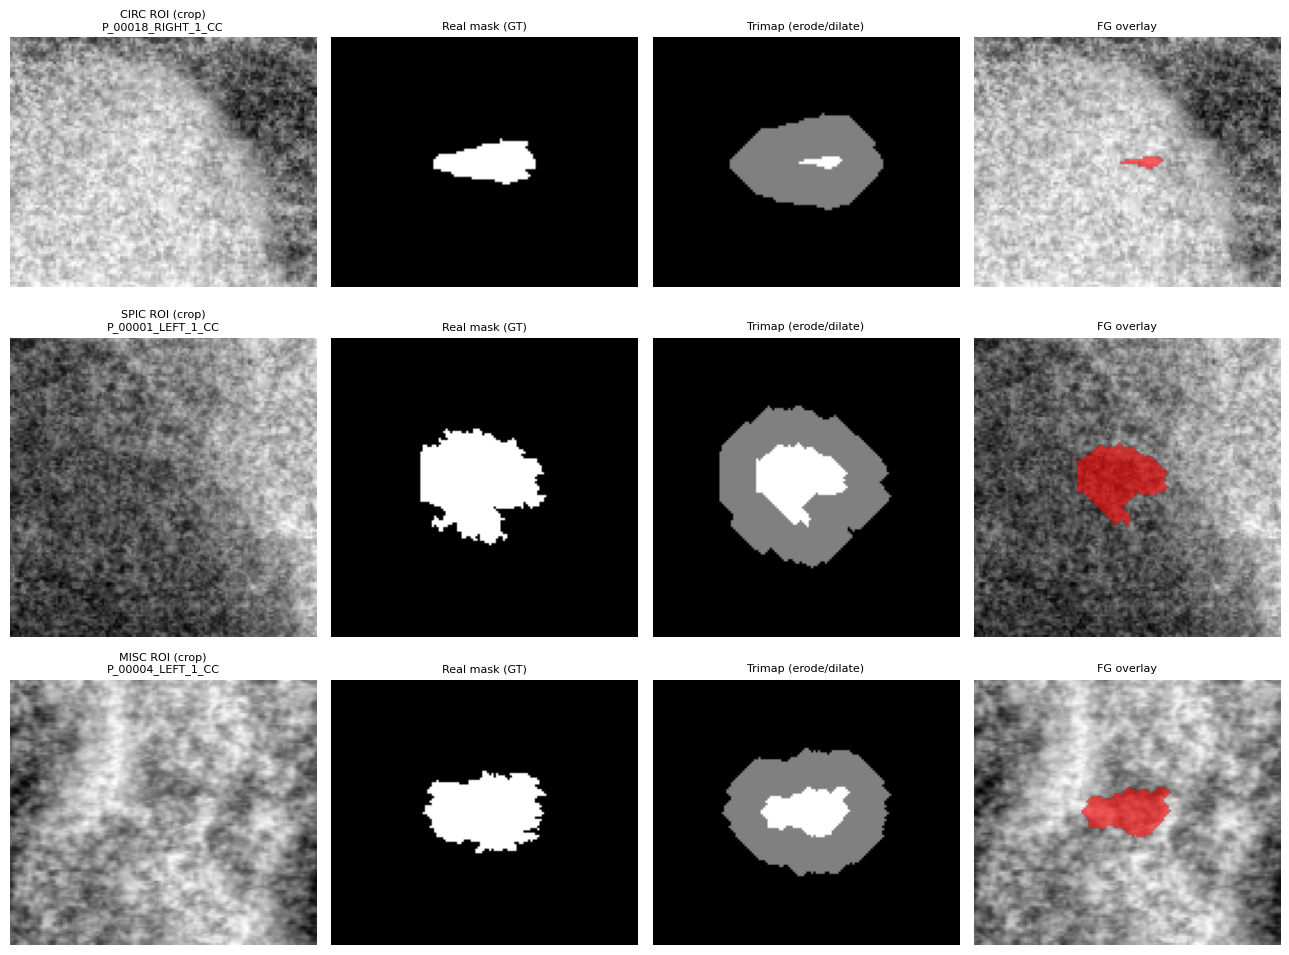

Saved section4_sample_verification.png


In [ ]:
# Verification figure 
def one_per_class(df, pool):
    out = {}
    for c in TARGET_CLASSES:
        for _, r in df[df['class'] == c].iterrows():
            if r['image_id'] in pool:
                out[c] = r['image_id']; break
    return out

picks = one_per_class(final_df_loaded, preprocessed_results)
n = len(picks)
fig, axes = plt.subplots(n, 4, figsize=(13, 3.3*n))
if n == 1: axes = axes.reshape(1, -1)
for r, (cls, iid) in enumerate(picks.items()):
    d = preprocessed_results[iid]
    axes[r,0].imshow(d['roi'], cmap='gray');        axes[r,0].set_title(f"{cls} ROI (crop)\n{iid[:28]}", fontsize=8)
    axes[r,1].imshow(d['gt_mask'], cmap='gray');    axes[r,1].set_title("Real mask (GT)", fontsize=8)
    axes[r,2].imshow(d['trimap'], cmap='gray');     axes[r,2].set_title("Trimap (erode/dilate)", fontsize=8)
    axes[r,3].imshow(d['roi'], cmap='gray')
    axes[r,3].imshow(np.ma.masked_where(d['trimap']!=255, d['trimap']), cmap='autumn', alpha=0.6)
    axes[r,3].set_title("FG overlay", fontsize=8)
    for c in range(4): axes[r,c].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "section4_sample_verification.png"), dpi=140, bbox_inches='tight')
plt.show()
print("Saved section4_sample_verification.png")

In [ ]:
# Final notebook verification
def verify_section34():
    checks = {
        "images loaded"        : len(preprocessed_results) > 0,
        "ROI in [0,1]"         : all(v['roi'].min() >= 0 and v['roi'].max() <= 1
                                     for v in preprocessed_results.values()),
        "trimap has 3 levels"  : all(set(np.unique(v['trimap'])) <= {0,128,255}
                                     for v in preprocessed_results.values()),
        "trimap has foreground": all((v['trimap']==255).sum() > 0
                                     for v in preprocessed_results.values()),
        "gt mask present"      : all(v['gt_mask'].max() > 0 for v in preprocessed_results.values()),
        "resolution capped"    : metadata_df[['roi_h','roi_w']].max().max() <= ROI_MAX_SIZE,
        "saved to Drive"       : os.path.exists(os.path.join(PREPROCESSED_DIR, "rois.npz")),
    }
    print("=" * 52); print("SECTIONS 3-4 VERIFICATION"); print("=" * 52)
    ok = True
    for k, v in checks.items():
        print(f"  {'OK ' if v else 'FAIL'}  {k}"); ok = ok and v
    print("=" * 52)
    print("Proceed to notebook 4." if ok else "Review failures.")
    return ok

verify_section34()

SECTIONS 3-4 VERIFICATION
  OK   images loaded
  OK   ROI in [0,1]
  OK   trimap has 3 levels
  OK   trimap has foreground
  OK   gt mask present
  OK   resolution capped
  OK   saved to Drive
Proceed to notebook 4.


True